In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

%matplotlib widget
plt.rc('text', usetex = True)
plt.rcParams['font.size'] = 16
plt.rcParams['figure.facecolor'] = 'w'
plt.style.use('classic')

In [54]:
thicknesses = [ '0.5' , '2.0']
materials = ['Be', 'Al']

def entrance_win_path(material: str, thickness: str):
    return f'/Users/max/SLAC Fall 2024/LXeSims/{material}_sigmaR_3mm_thickness_{thickness}mm/entrance_window.csv'

def exit_win_path(material: str, thickness: str):
    return f'/Users/max/SLAC Fall 2024/LXeSims/{material}_sigmaR_3mm_thickness_{thickness}mm/exit_window.csv'

def LXe_path(material: str, thickness: str):
    return f'/Users/max/SLAC Fall 2024/LXeSims/{material}_sigmaR_3mm_thickness_{thickness}mm/LXe.csv'

def Silviu_entrance_win_path(material: str, thickness: str):
    return f'/Users/max/SLAC Fall 2024/LXeSims/{material}_sigmaR_3mm_thickness_{thickness}mm/Silviu_entrance_window.csv'

def Silviu_exit_win_path(material: str, thickness: str):
    return f'/Users/max/SLAC Fall 2024/LXeSims/{material}_sigmaR_3mm_thickness_{thickness}mm/Silviu_exit_window.csv'

def Silviu_LXe_path(material: str, thickness: str):
    return f'/Users/max/SLAC Fall 2024/LXeSims/{material}_sigmaR_3mm_thickness_{thickness}mm/Silviu_LXe.csv'

def spherical_z(x, y, z, radius, exit=False):
    '''
    Projects window z-data to spherical shell segment.
    '''
    # everything in meters!
    # to get entrance window z correctly, you must feed in the exit window z-value!
    if exit:
        return np.sqrt(radius**2 - x**2 - y**2) - (radius - z) # - (np.sqrt(radius**2 - 2 * 0.035**2) - radius)
    else:
        return 0.1 - spherical_z(x, y, z, radius, True)

radius = 0.175

# Check warp calculation

In [38]:
z = 0.101
print(spherical_z(0.035,0.035, z, radius, exit=True))
print(spherical_z(0.035,0.0, z, radius, exit=True))
print(spherical_z(0.0,0.0, z, radius, exit=False))

0.09385410331594518
0.09746428199482246
-0.0010000000000000009


In [79]:
x = np.linspace(-0.035, 0.035, 100)
x3 = np.linspace(-0.035, 0.035, 400)

X,Y = np.meshgrid(x3,x3)

zen = spherical_z(x, 0.035, z, radius, exit=False)
zex = spherical_z(x, 0.035, z, radius, exit=True)
zen_center = spherical_z(x, 0, z, radius, exit=False)
zex_center = spherical_z(x, 0, z, radius, exit=True)
zex3 = spherical_z(X, Y, z, radius, exit=True)

0.09746391752422376
0.10099964289321794


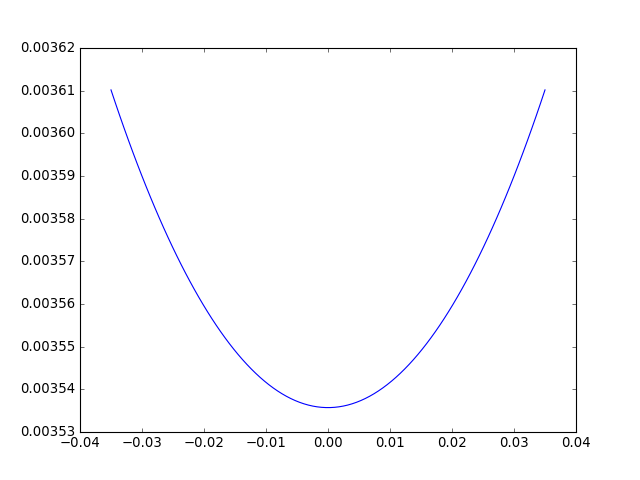

In [80]:
print(zex[49])
print(zex_center[49])

plt.close()
plt.figure()

plt.plot(x, zex_center - zex)

plt.show()

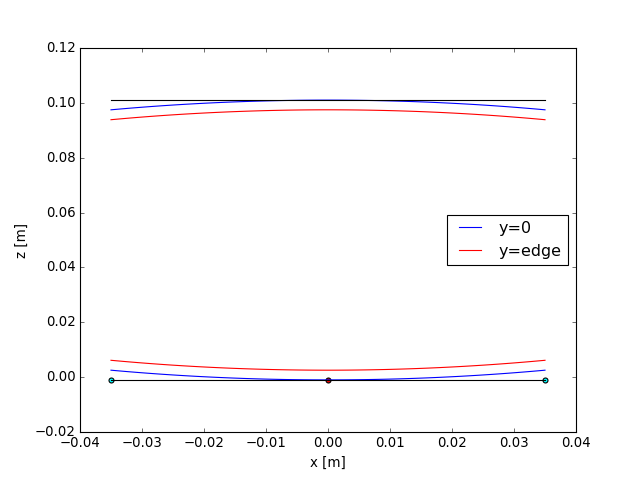

In [83]:
plt.close()
plt.figure()

plt.plot(x, zen_center, c='b', label='y=0')
plt.plot(x, zex_center, c='b', label='_')

plt.plot(x, zen, c='r', label='y=edge')
plt.plot(x, zex, c='r', label='_')

plt.axhline(y=0.101, xmin=0.005/0.08, xmax=0.075/0.08, c='k', label='_')
plt.axhline(y=-0.001, xmin=0.005/0.08, xmax=0.075/0.08, c='k', label='_')

plt.scatter([-0.035, 0.035], [-0.001, -0.001], c='cyan', label='_')
plt.scatter([0.], [-0.001], c='r', edgecolors='k', label='_')

plt.xlabel('x [m]')
plt.ylabel('z [m]')
plt.legend(loc='best')

# plt.ylim(0.09, 0.101)

plt.show()

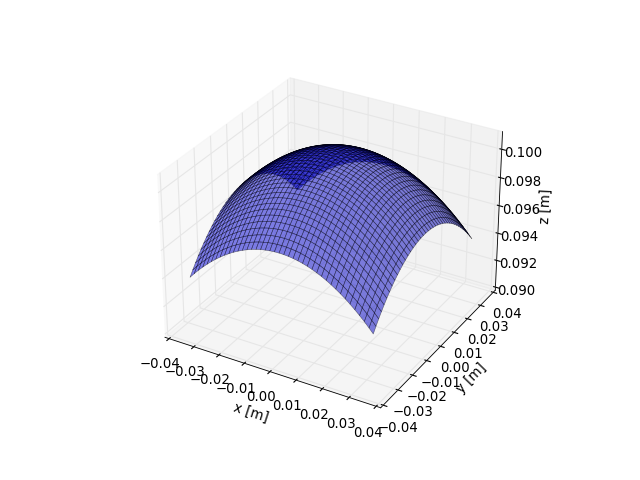

In [59]:
plt.close()
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

ax.plot_surface(X, Y, zex3.T, alpha=0.5, linewidth=0.5, edgecolor='black')

ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_zlabel('z [m]')

ax.set_zlim(0.09, 0.101)

plt.show()

# Modify a copy of the csv data

In [3]:
print([[mat,thk] for thk in thicknesses for mat in materials])

entrance_data = [pd.read_csv(Silviu_entrance_win_path(mat, thk)) for thk in thicknesses for mat in materials]
exit_data = [pd.read_csv(Silviu_exit_win_path(mat, thk)) for thk in thicknesses for mat in materials]

[['Be', '0.5'], ['Al', '0.5'], ['Be', '2.0'], ['Al', '2.0']]


In [41]:
for i in range(4):
    entrance_data[i]['z'] = spherical_z(entrance_data[i]['x'], entrance_data[i]['y'], exit_data[i]['z'], radius, exit=False)
    exit_data[i]['z'] = spherical_z(exit_data[i]['x'], exit_data[i]['y'], exit_data[i]['z'], radius, exit=True)

### Plot check

-0.0005 -0.0005 0.10099857142274038


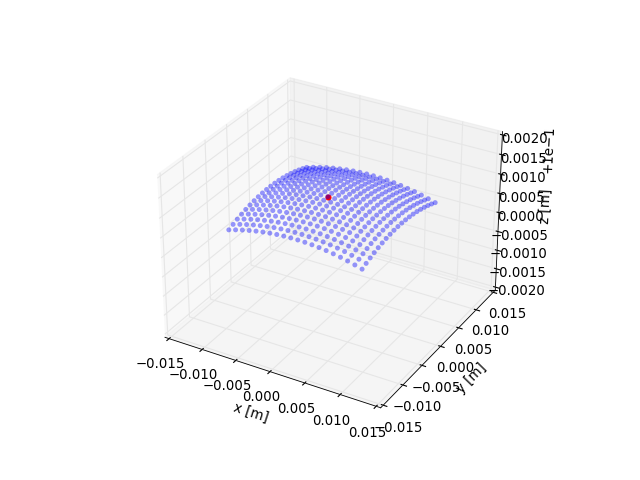

In [97]:
idx = 2

plt.close()
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# ax.scatter3D(entrance_data[idx]['x'], entrance_data[idx]['y'], entrance_data[idx]['z'], edgecolor='none', facecolor='b')
ax.scatter3D(exit_data[idx]['x'], exit_data[idx]['y'], exit_data[idx]['z'], edgecolor='none', facecolor='b', alpha=0.4)

# test
test_idx = 189
ax.scatter3D(exit_data[idx]['x'][test_idx], exit_data[idx]['y'][test_idx], exit_data[idx]['z'][test_idx], edgecolor='r', facecolor='r')
print(exit_data[idx]['x'][test_idx], exit_data[idx]['y'][test_idx], exit_data[idx]['z'][test_idx])

ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_zlabel('z [m]')

ax.set_zlim(0.098, 0.102)

plt.show()

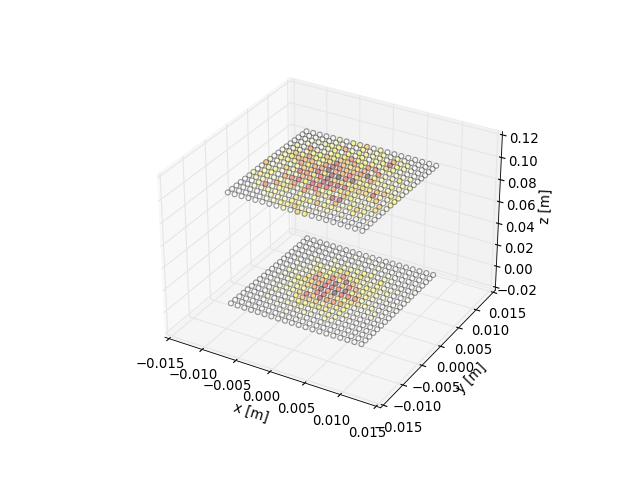

In [78]:
idx = 2

plt.close()
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

ax.scatter3D(entrance_data[idx]['x'], entrance_data[idx]['y'], entrance_data[idx]['z'], c=entrance_data[idx]['PowerPerVolume'], cmap='hot_r', alpha=0.4)
ax.scatter3D(exit_data[idx]['x'], exit_data[idx]['y'], exit_data[idx]['z'], c=exit_data[idx]['PowerPerVolume'], cmap='hot_r', alpha=0.4)

ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_zlabel('z [m]')

# ax.set_title('Entrance window')
# ax.set_zlim(-0.002, 0.002)

# ax.set_title('Exit window')
# ax.set_zlim(0.098, 0.102)

plt.show()

In [67]:
idx = 2

print(entrance_data[idx]['z'].min(), entrance_data[idx]['z'].max())
print(exit_data[idx]['z'].min(), exit_data[idx]['z'].max())

-0.0009971428454808584 3.2952845114730955e-05
0.09996704715488527 0.10099714284548086


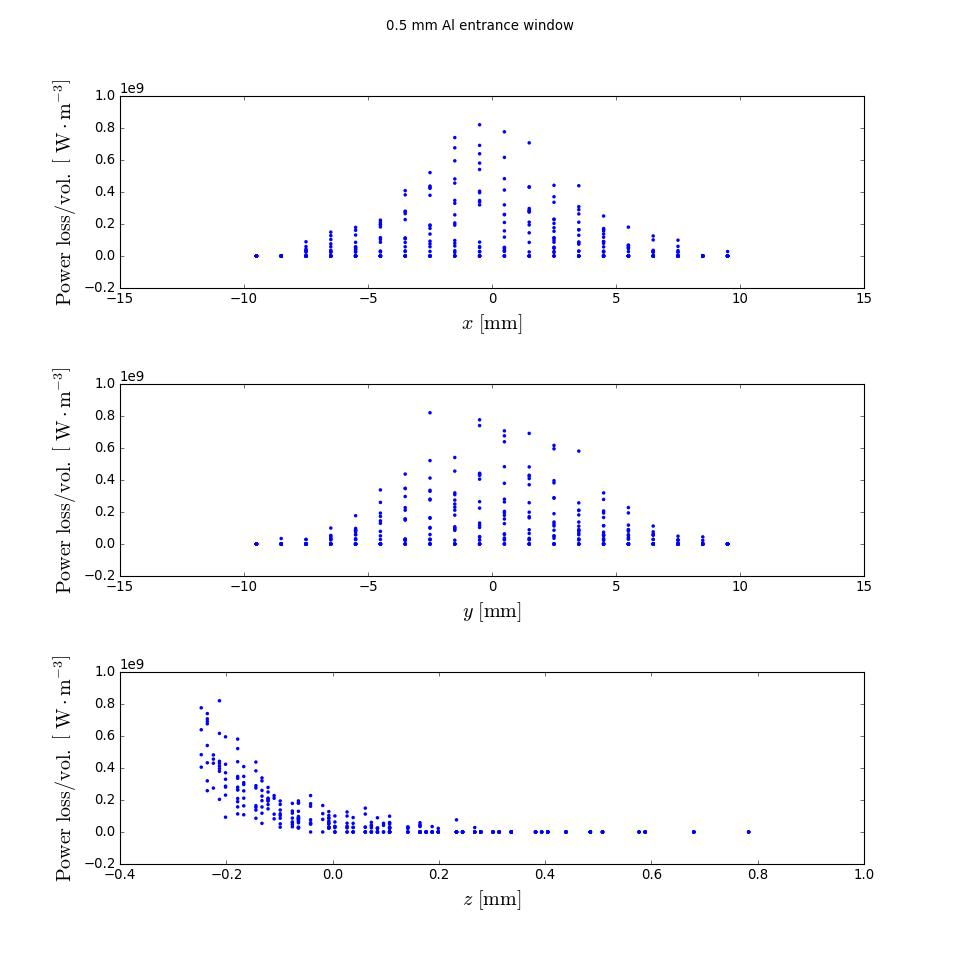

In [64]:
# plt.close()
# plt.figure()
# plt.scatter(entrance_data[1]['x'], entrance_data[1]['PowerPerVolume'], edgecolors='none')
# plt.show()

idx=1

plt.close()
fig, ax = plt.subplots(3, 1, figsize=(12,12), gridspec_kw={'hspace': 0.5})


ax[0].scatter(1e3 * entrance_data[idx]['x'], entrance_data[idx]['PowerPerVolume'], marker='o', facecolors='b', s=10, edgecolors='none')
ax[0].set_xlabel(r'$x\ [\mathrm{mm}]$', fontsize=18)

ax[1].scatter(1e3 * entrance_data[idx]['y'], entrance_data[idx]['PowerPerVolume'], marker='o', facecolors='b', s=10, edgecolors='none')
ax[1].set_xlabel(r'$y\ [\mathrm{mm}]$', fontsize=18)

ax[2].scatter(1e3 * entrance_data[idx]['z'], entrance_data[idx]['PowerPerVolume'], marker='o', facecolors='b', s=10, edgecolors='none')
ax[2].set_xlabel(r'$z\ [\mathrm{mm}]$', fontsize=18)

for i in range(3):
    ax[i].set_ylabel(r'$\mathrm{Power\ loss/vol.}\ \left[\ \mathrm{W}\cdot \mathrm{m}^{-3}\right]$', fontsize=18)


plt.suptitle(f'0.5 mm Al entrance window')
plt.show()

# Export new data

In [79]:
zip_path = '/Users/max/SLAC Fall 2024/LXeSims/warped_z_zips'
os.makedirs(zip_path, exist_ok=True)

import subprocess

for i,thickness in enumerate(thicknesses):
    for j,material in enumerate(materials):
        idx = 2*i + j
        # print(material, thickness, idx)
        path = f'/Users/max/SLAC Fall 2024/LXeSims/{material}_sigmaR_3mm_thickness_{thickness}mm'
        entrance_file = path+"/Warped_z_Silviu_entrance_window.csv"
        exit_file = path+"/Warped_z_Silviu_exit_window.csv"
        entrance_data[i].to_csv(entrance_file, index=False)
        exit_data[i].to_csv(exit_file, index=False)

        LXe_file = path+"/Silviu_LXe.csv"

        subprocess.run([
            "zip", "-j", # j flag makes sure only the file names are kept in the zip and not the entire paths
            f"{zip_path}/Warped_z_{material}_{thickness}mm.zip",
            LXe_file,
            entrance_file,
            exit_file
        ])

  adding: Silviu_LXe.csv (deflated 87%)
  adding: Warped_z_Silviu_entrance_window.csv (deflated 81%)
  adding: Warped_z_Silviu_exit_window.csv (deflated 78%)
  adding: Silviu_LXe.csv (deflated 87%)
  adding: Warped_z_Silviu_entrance_window.csv (deflated 81%)
  adding: Warped_z_Silviu_exit_window.csv (deflated 78%)
  adding: Silviu_LXe.csv (deflated 87%)
  adding: Warped_z_Silviu_entrance_window.csv (deflated 81%)
  adding: Warped_z_Silviu_exit_window.csv (deflated 77%)
  adding: Silviu_LXe.csv (deflated 87%)
  adding: Warped_z_Silviu_entrance_window.csv (deflated 81%)
  adding: Warped_z_Silviu_exit_window.csv (deflated 77%)
